# XAI-project — Interpretable Prediction of Mega-Fires in Chile

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera  
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** Exploratory analysis of the CONAF historical wildfire registry (2002–2020): heavy-tailed burned-area distribution, spatial maps, and seasonality.

**How to run:** requires the cleaned/enriched parquet in `data/` (run `python scripts/preprocess.py` first, or extract `conaf_enriched_latest.tar.gz`).

> See the repository [`README.md`](../README.md) for setup, the data pipeline, and reproduction steps.

# EDA -- CONAF historical wildfire record

Exploratory analysis of the historical record of wildfires identified by CONAF between the 2002-2003 and 2019-2020 seasons.

**Goal**: characterize events, alerts, scenarios, temporal/spatial distribution, duration and burned area to inform downstream modeling. This notebook uses only clean CONAF data via `load_conaf()`; it does not incorporate ERA5 or enriched datasets.

## Source and variables

Public source: [Datos para Resiliencia / itrend](https://datospararesiliencia.cl/dataset.xhtml?persistentId=doi:10.71578/UXAUN5), DOI `10.71578/UXAUN5`.

The record includes, per event:

- **Location**: region, province, commune, latitude, longitude and datum of the estimated ignition point.
- **Date**: season, date, start time and duration in minutes.
- **Event info**: name, issued alert, scenario and cause.
- **Burned area**: breakdown by pine A/B/C, eucalyptus, other plants, woodland, scrub, grassland, agricultural, debris and total in hectares.

## Scenario glossary

- `IFor-PI`: plantation wildfire; mainly affects forest plantations and forest-management debris.
- `IFor-Vn`: natural-vegetation wildfire; affects mature forest, regrowth, scrub, native debris and occasionally agricultural soils.
- `IFIUr-Fo`: wildland-urban interface wildfire; threatens or affects vegetation and populated, industrial or productive-infrastructure areas. In the original description it may appear as `FIUr-Fo`.
- `IFCo`: mountain wildfire; occurs above 1,000 m.a.s.l. with complex ground access and aerial operations.
- `IFSu`: subsurface wildfire; smoldering underground spread after surface extinction.
- `IFCSo`: social-conflict wildfire; occurs in territories defined as social/territorial conflict zones.
- `IFASP`: wildfire in a SNASPE Protected Wildland Area.
- `IFIns`: insular wildfire; occurs on islands or archipelagos with sea or air access.
- `No definido`: records without a specific reported scenario.

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/xai-project-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

cwd = Path.cwd()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(ROOT) not in sys.path:
	sys.path.insert(0, str(ROOT))

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.conaf_loader import load_conaf

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10

# --- Constants ---
POWER_LAW_QUANTILES = [0.90, 0.75, 0.50]  # tail quantiles in priority order
FIT_MIN_BINS = 5                            # minimum bins for a valid fit
LOG_BINS_COUNT = 50                         # log-scale bins for histograms
PARETO_THRESHOLD_HIGH = 1_000              # min events to classify as high support
PARETO_THRESHOLD_MED = 200                 # min events to classify as medium support

SUP_TOTAL = "superficie_quemada_total_ha"
VEG_COLS = [
	"superficie_quemada_pino_a_ha",
	"superficie_quemada_pino_b_ha",
	"superficie_quemada_pino_c_ha",
	"superficie_quemada_eucalipto_ha",
	"superficie_quemada_otras_plantas_ha",
	"superficie_quemada_arbolado_ha",
	"superficie_quemada_matorral_ha",
	"superficie_quemada_pastizal_ha",
	"superficie_quemada_agricola_ha",
	"superficie_quemada_desechos_ha",
]

# --- Formatting helpers ---
def fmt_int(value):
	"""Formatea un entero con punto como separador de miles (es-CL)."""
	return f"{int(value):,}".replace(",", ".")

def fmt_ha(value):
	"""Formatea hectáreas con un decimal y separadores es-CL (punto miles, coma decimal)."""
	return f"{float(value):,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")

def pct(value):
	"""Formatea una fracción como porcentaje con un decimal y coma decimal (es-CL)."""
	return f"{100 * float(value):.1f}%".replace(".", ",")

# --- Analysis helpers ---
def make_log_bins(series, n_bins=LOG_BINS_COUNT):
	"""Construye bins espaciados logarítmicamente para una serie de valores positivos.

	Coacciona la serie a numérica, descarta NaN y valores no positivos (incompatibles
	con la log-scale) y reparte n_bins entre el mínimo y el máximo en base log10.

	Args:
		series: Serie de valores a binnear (p. ej. superficie quemada en ha).
		n_bins: Número de bordes de bin a generar.

	Returns:
		np.ndarray con los bordes de los bins en log-scale.
	"""
	s = pd.to_numeric(series, errors="coerce").dropna()
	s = s[s > 0]
	return np.logspace(np.log10(s.min()), np.log10(s.max()), n_bins)


def categorical_summary(df, column):
	"""Resume eventos y superficie quemada agrupando por una variable categórica.

	Args:
		df: DataFrame de eventos; debe incluir la columna `superficie_total_ha`.
		column: Nombre de la columna categórica por la que agrupar (p. ej. región).

	Returns:
		DataFrame indexado por categoría con el conteo de eventos, la superficie total
		y mediana en ha, y la fracción de eventos (`pct_eventos`), ordenado por número
		de eventos descendente.
	"""
	return (
		df.groupby(column)
		.agg(
			eventos=(column, "size"),
			superficie_total_ha=("superficie_total_ha", "sum"),
			superficie_mediana_ha=("superficie_total_ha", "median"),
		)
		.assign(pct_eventos=lambda x: x["eventos"] / len(df))
		.sort_values("eventos", ascending=False)
	)


def fit_noncumulative_power_law(values, tail_quantile=POWER_LAW_QUANTILES[0], min_fit_bins=FIT_MIN_BINS):
	"""Fit p(A) ~ A^{-beta} over the tail of the non-cumulative distribution in log-log space.

	Construye un histograma en log-scale, lo convierte a densidad y ajusta una recta por
	mínimos cuadrados sobre la cola (a partir del cuantil indicado). Si la cola no reúne
	suficientes bins, relaja el cuantil siguiendo `POWER_LAW_QUANTILES`.

	Args:
		values: Valores positivos a ajustar (p. ej. superficie quemada en ha).
		tail_quantile: Cuantil inicial que define el inicio de la cola (xmin).
		min_fit_bins: Mínimo de bins con densidad válida para aceptar el ajuste.

	Returns:
		dict con los parámetros del fit (beta, pendiente, intercepto, xmin_ha, cola usada,
		bins y eventos en la cola, y r2 en log-log), o None si no hay datos suficientes.
	"""
	data = pd.to_numeric(values, errors="coerce").dropna().astype(float)
	data = data[data > 0]
	if len(data) < 30 or data.nunique() < 3:
		return None

	bins_count = int(np.clip(np.sqrt(len(data)) * 2, 12, LOG_BINS_COUNT))
	bins = np.logspace(np.log10(data.min()), np.log10(data.max()), bins_count)
	counts, edges = np.histogram(data, bins=bins)
	bin_widths = np.diff(edges)
	bin_centers = np.sqrt(edges[:-1] * edges[1:])
	density = counts / (counts.sum() * bin_widths)

	fit_quantile = tail_quantile
	fit_mask = (counts > 0) & np.isfinite(density) & (density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < min_fit_bins:
		fit_quantile = POWER_LAW_QUANTILES[1]
		fit_mask = (counts > 0) & np.isfinite(density) & (density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < min_fit_bins:
		fit_quantile = POWER_LAW_QUANTILES[2]
		fit_mask = (counts > 0) & np.isfinite(density) & (density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < 3:
		return None

	log_x = np.log10(bin_centers[fit_mask])
	log_y = np.log10(density[fit_mask])
	slope, intercept = np.polyfit(log_x, log_y, 1)
	pred_log_y = intercept + slope * log_x
	ss_res = np.sum((log_y - pred_log_y) ** 2)
	ss_tot = np.sum((log_y - log_y.mean()) ** 2)

	return {
		"eventos_positivos": int(len(data)),
		"beta": float(-slope),
		"pendiente": float(slope),
		"intercepto": float(intercept),
		"xmin_ha": float(data.quantile(fit_quantile)),
		"cola_usada": f"p{int(fit_quantile * 100)}",
		"bins_usados": int(fit_mask.sum()),
		"eventos_en_cola": int(counts[fit_mask].sum()),
		"r2_log_log": float(1 - ss_res / ss_tot) if ss_tot else np.nan,
	}

## 2. Load and overview

In [2]:
gdf = load_conaf()
df = pd.DataFrame(gdf.drop(columns="geometry", errors="ignore")).copy()

required = {
	"region",
	"provincia",
	"comuna",
	"temporada",
	"fecha_hora_inicio",
	"duracion_minutos",
	"alerta",
	"escenario",
	"causa",
	SUP_TOTAL,
	"latitud",
	"longitud",
}
missing_required = sorted(required - set(df.columns))
if missing_required:
	raise KeyError(f"Missing required columns: {missing_required}")

df["fecha_hora_inicio"] = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
df["fecha_hora_inicio_utc"] = pd.to_datetime(df["fecha_hora_inicio_utc"], errors="coerce")
df["superficie_total_ha"] = pd.to_numeric(df[SUP_TOTAL], errors="coerce")
df["duracion_horas"] = pd.to_numeric(df["duracion_minutos"], errors="coerce") / 60
df["anio"] = df["fecha_hora_inicio"].dt.year
df["mes"] = df["fecha_hora_inicio"].dt.month
day_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df["dia_semana"] = df["fecha_hora_inicio"].dt.dayofweek.map(day_names)
df["hora"] = df["fecha_hora_inicio"].dt.hour

df.head(3)

INFO: Cargando cache limpio: /home/imorales/Desktop/XAI/XAI-project/data/interim/conaf_clean.parquet


,region,provincia,comuna,temporada,nombre,fecha,hora_inicio,duracion_minutos,alerta,escenario,causa,superficie_quemada_pino_a_ha,superficie_quemada_pino_b_ha,superficie_quemada_pino_c_ha,superficie_quemada_eucalipto_ha,superficie_quemada_otras_plantas_ha,superficie_quemada_arbolado_ha,superficie_quemada_matorral_ha,superficie_quemada_pastizal_ha,superficie_quemada_agricola_ha,superficie_quemada_desechos_ha,superficie_quemada_total_ha,latitud,longitud,datum,fecha_hora_inicio,fecha_hora_inicio_utc,superficie_total_ha,duracion_horas,anio,mes,dia_semana,hora
0,Coquimbo,Elqui,La Serena,2002-2003,ALTOVALSOL,2002-07-05,21:05,195.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.00,0.04,-29.94,-71.11,WGS84,2002-07-05 21:05:00,2002-07-06 01:05:00,0.04,3.25,2002,7,Fri,21
1,Coquimbo,Elqui,La Serena,2002-2003,CERES,2002-10-25,11:50,137.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.02,-29.93,-71.21,WGS84,2002-10-25 11:50:00,2002-10-25 14:50:00,0.02,2.28,2002,10,Fri,11
2,Coquimbo,Limarí,Punitaqui,2002-2003,LA RINCONADA,2002-10-27,11:50,190.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.01,-30.83,-71.37,WGS84,2002-10-27 11:50:00,2002-10-27 14:50:00,0.01,3.17,2002,10,Sun,11


In [3]:
overview = pd.DataFrame(
	{
		"metric": [
			"Records",
			"Columns",
			"Seasons",
			"Local time range",
			"Total burned area (ha)",
			"Median per event (ha)",
		],
		"value": [
			fmt_int(len(df)),
			fmt_int(df.shape[1]),
			f"{df['temporada'].min()} to {df['temporada'].max()} ({df['temporada'].nunique()} seasons)",
			f"{df['fecha_hora_inicio'].min()} to {df['fecha_hora_inicio'].max()}",
			fmt_ha(df["superficie_total_ha"].sum()),
			fmt_ha(df["superficie_total_ha"].median()),
		],
	}
)
display(overview)

,metric,value
0,Records,109.947
1,Columns,33
2,Seasons,2002-2003 to 2019-2020 (18 seasons)
3,Local time range,2002-07-01 14:00:00 to 2020-06-21 20:59:00
4,Total burned area (ha),"1.562.870,0"
5,Median per event (ha),"0,3"


In [4]:
dtypes = (
	df.dtypes.astype(str)
	.rename("dtype")
	.reset_index()
	.rename(columns={"index": "column"})
)
display(dtypes)

,column,dtype
0,region,str
1,provincia,str
2,comuna,str
3,temporada,str
4,nombre,str
5,fecha,datetime64[us]
6,hora_inicio,str
7,duracion_minutos,float64
8,alerta,str
9,escenario,str


## 3. Data quality

In [5]:
lat = pd.to_numeric(df["latitud"], errors="coerce")
lon = pd.to_numeric(df["longitud"], errors="coerce")
sup = df["superficie_total_ha"]
duration = pd.to_numeric(df["duracion_minutos"], errors="coerce")
chile_bbox = lat.between(-42, -34) & lon.between(-74, -70)

quality = pd.DataFrame(
	{
		"check": [
			"Exact duplicates",
			"Null local timestamp",
			"Null derived UTC timestamp",
			"Missing coordinates",
			"Outside study bbox (Maule/Biobio/Araucania/Los Rios)",
			"Null total area",
			"Negative total area",
			"Zero total area",
			"Null duration",
			"Negative duration",
		],
		"records": [
			int(df.duplicated().sum()),
			int(df["fecha_hora_inicio"].isna().sum()),
			int(df["fecha_hora_inicio_utc"].isna().sum()),
			int((lat.isna() | lon.isna()).sum()),
			int((~chile_bbox & lat.notna() & lon.notna()).sum()),
			int(sup.isna().sum()),
			int((sup < 0).sum()),
			int((sup == 0).sum()),
			int(duration.isna().sum()),
			int((duration < 0).sum()),
		],
	}
)
quality["percentage"] = quality["records"] / len(df)
display(quality.style.format({"records": "{:,}", "percentage": "{:.2%}"}))

,check,records,percentage
0,Exact duplicates,0,0.00%
1,Null local timestamp,0,0.00%
2,Null derived UTC timestamp,6,0.01%
3,Missing coordinates,0,0.00%
4,Outside study bbox (Maule/Biobio/Araucania/Los Rios),"25,224",22.94%
5,Null total area,0,0.00%
6,Negative total area,0,0.00%
7,Zero total area,170,0.15%
8,Null duration,0,0.00%
9,Negative duration,"1,338",1.22%


,column,null_proportion,nulls
0,fecha_hora_inicio_utc,0.01%,6
1,region,0.00%,0
2,provincia,0.00%,0
3,temporada,0.00%,0
4,comuna,0.00%,0
5,fecha,0.00%,0
6,hora_inicio,0.00%,0
7,duracion_minutos,0.00%,0
8,nombre,0.00%,0
9,escenario,0.00%,0


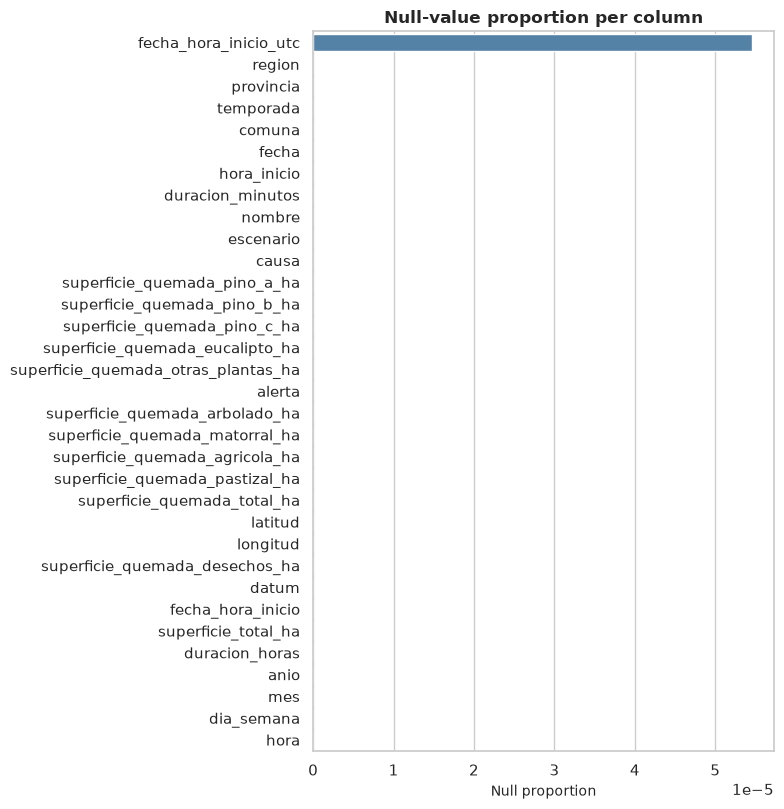

In [6]:
missing = (
	df.isna()
	.mean()
	.sort_values(ascending=False)
	.rename("null_proportion")
	.reset_index()
	.rename(columns={"index": "column"})
)
missing["nulls"] = (missing["null_proportion"] * len(df)).round().astype(int)
display(missing.head(15).style.format({"null_proportion": "{:.2%}", "nulls": "{:,}"}))

plt.figure(figsize=(8, max(4, len(missing) * 0.25)))
sns.barplot(data=missing, x="null_proportion", y="column", color="steelblue")
plt.title("Null-value proportion per column")
plt.xlabel("Null proportion")
plt.ylabel("")
plt.tight_layout()

## 4. Per-season summary

In [7]:
alert_types = (
	df.groupby("temporada")["alerta"]
	.apply(lambda s: ", ".join(f"{name} ({fmt_int(count)})" for name, count in s.value_counts().items()))
	.rename("alertas_emitidas")
)

season_summary = (
	df.groupby("temporada")
	.agg(
		eventos=("temporada", "size"),
		superficie_total_ha=("superficie_total_ha", "sum"),
		superficie_mediana_ha=("superficie_total_ha", "median"),
		duracion_mediana_min=("duracion_minutos", "median"),
		regiones=("region", "nunique"),
		comunas=("comuna", "nunique"),
	)
	.join(alert_types)
)
season_summary["ha_por_evento"] = season_summary["superficie_total_ha"] / season_summary["eventos"]
display(
	season_summary[
		[
			"eventos",
			"alertas_emitidas",
			"superficie_total_ha",
			"ha_por_evento",
			"superficie_mediana_ha",
			"duracion_mediana_min",
			"regiones",
			"comunas",
		]
	].style.format(
		{
			"eventos": "{:,}",
			"superficie_total_ha": "{:,.1f}",
			"ha_por_evento": "{:,.2f}",
			"superficie_mediana_ha": "{:,.2f}",
			"duracion_mediana_min": "{:,.0f}",
			"regiones": "{:,}",
			"comunas": "{:,}",
		}
	)
)

,eventos,alertas_emitidas,superficie_total_ha,ha_por_evento,superficie_mediana_ha,duracion_mediana_min,regiones,comunas
temporada,,,,,,,,
2002-2003,"7,394",Sin alerta (7.394),"41,531.4",5.62,0.20,91,10,235
2003-2004,"6,164",Sin alerta (6.164),"49,182.1",7.98,0.30,121,11,232
2004-2005,"6,411",Sin alerta (6.411),"61,569.6",9.60,0.30,123,11,228
2005-2006,"5,173",Sin alerta (5.173),"16,674.1",3.22,0.20,111,11,235
2006-2007,"4,986",Sin alerta (4.986),"40,200.3",8.06,0.20,95,9,232
2007-2008,"6,528",Sin alerta (6.528),"35,238.5",5.40,0.30,130,10,234
2008-2009,"5,913",Sin alerta (5.913),"54,687.0",9.25,0.30,135,10,229
2009-2010,"4,067",Sin alerta (4.067),"56,095.3",13.79,0.30,120,11,226
2010-2011,"4,922",Sin alerta (4.922),"39,832.7",8.09,0.30,112,11,245


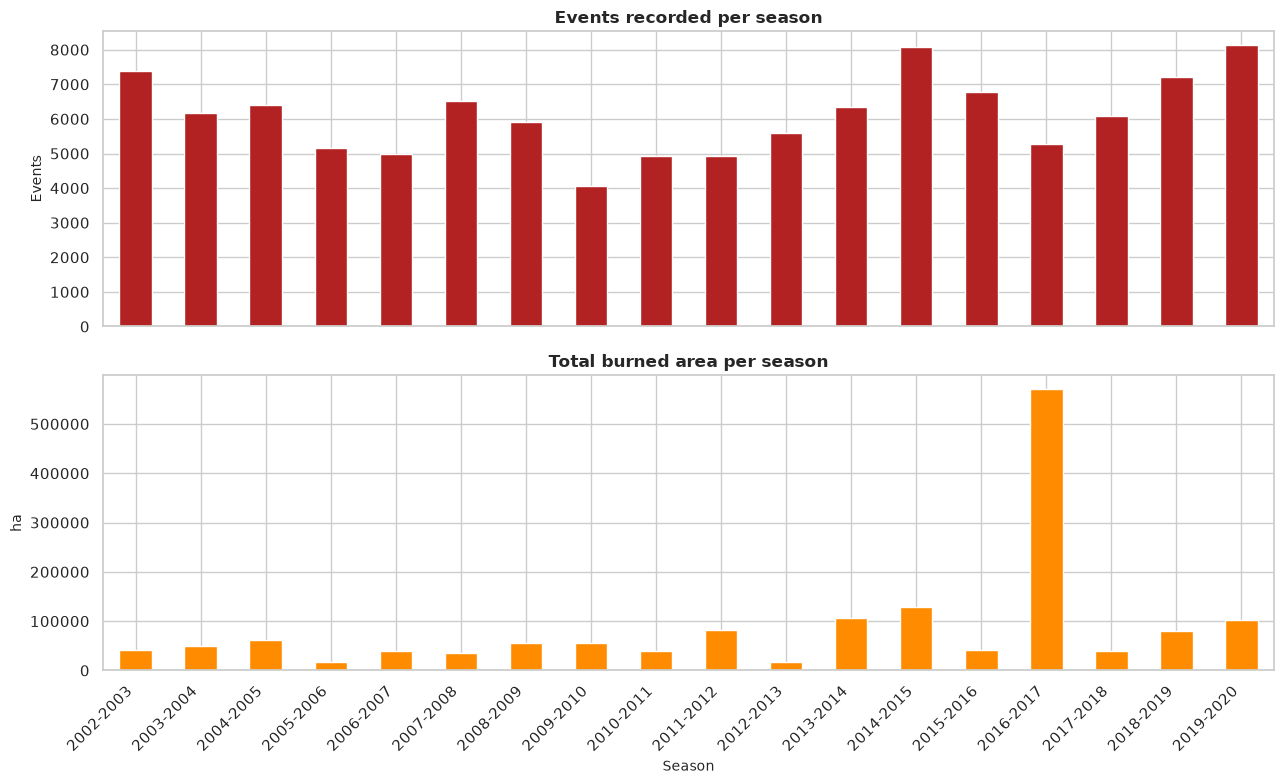

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
season_summary["eventos"].plot(kind="bar", ax=axes[0], color="firebrick")
axes[0].set_title("Events recorded per season")
axes[0].set_ylabel("Events")
season_summary["superficie_total_ha"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Total burned area per season")
axes[1].set_ylabel("ha")
axes[1].set_xlabel("Season")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

alerta,Alerta amarilla,Alerta roja,Sin alerta
temporada,,,
2002-2003,0,0,"7,394"
2003-2004,0,0,"6,164"
2004-2005,0,0,"6,411"
2005-2006,0,0,"5,173"
2006-2007,0,0,"4,986"
2007-2008,0,0,"6,528"
2008-2009,0,0,"5,913"
2009-2010,0,0,"4,067"
2010-2011,0,0,"4,922"


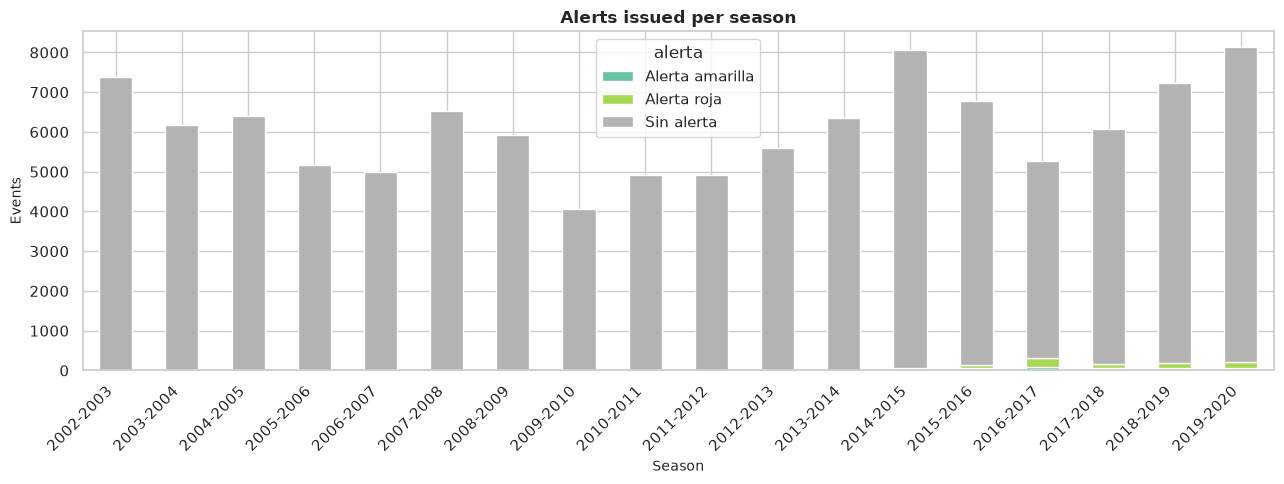

In [9]:
alert_by_season = pd.crosstab(df["temporada"], df["alerta"]).reindex(season_summary.index)
display(alert_by_season.style.format("{:,}"))

alert_by_season.plot(kind="bar", stacked=True, figsize=(13, 5), colormap="Set2")
plt.title("Alerts issued per season")
plt.xlabel("Season")
plt.ylabel("Events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## 5. Temporal distribution

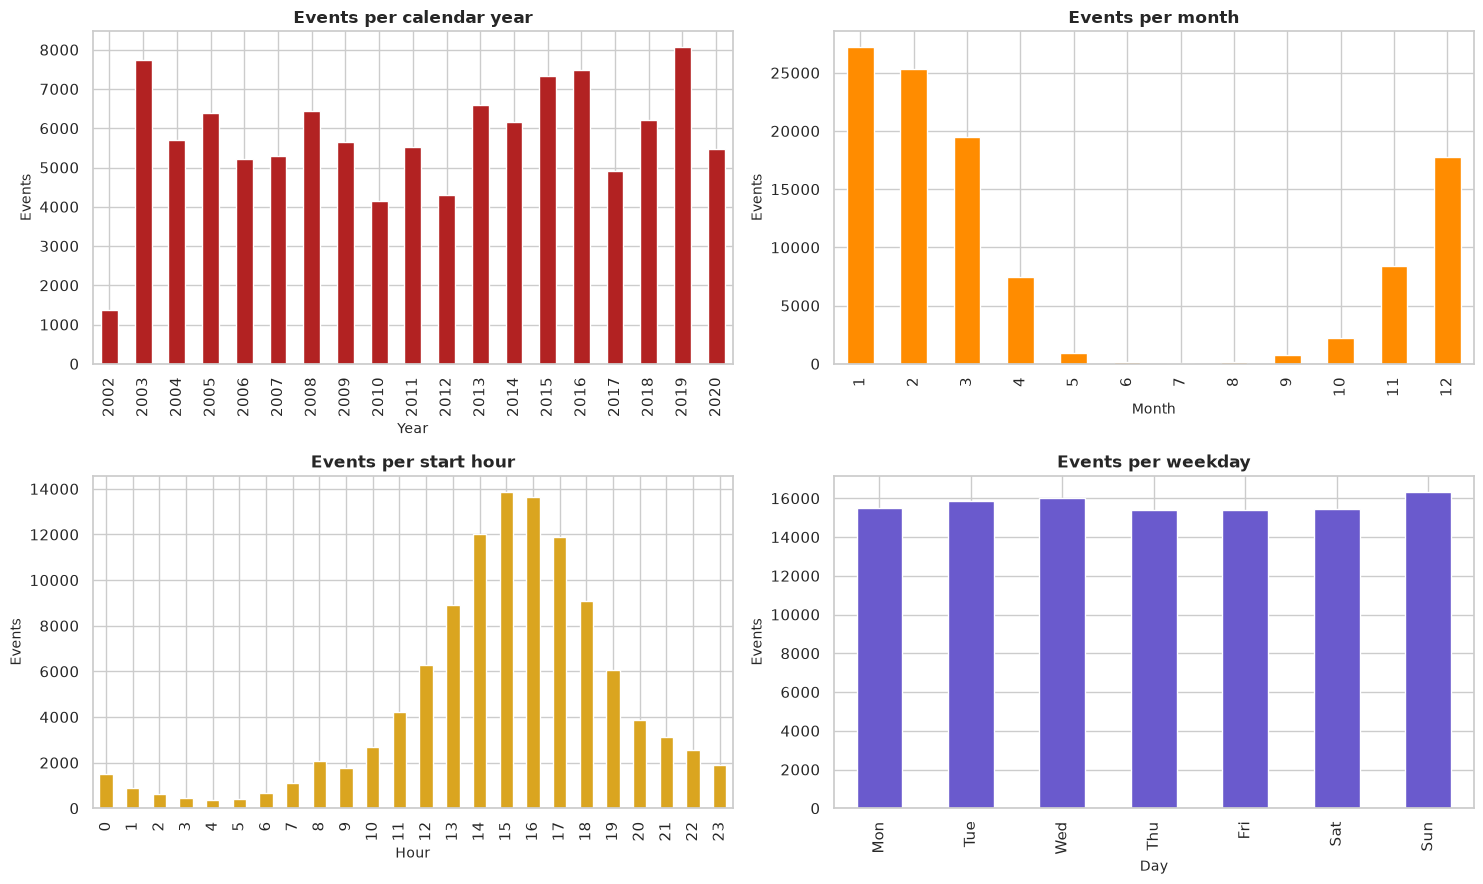

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

df["anio"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="firebrick")
axes[0, 0].set_title("Events per calendar year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Events")

df["mes"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Events per month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Events")

df["hora"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0], color="goldenrod")
axes[1, 0].set_title("Events per start hour")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Events")

weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_counts = df["dia_semana"].value_counts().reindex(weekday_order)
weekday_counts.plot(kind="bar", ax=axes[1, 1], color="slateblue")
axes[1, 1].set_title("Events per weekday")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Events")

plt.tight_layout()

In [11]:
month_summary = (
	df.groupby("mes")
	.agg(eventos=("mes", "size"), superficie_total_ha=("superficie_total_ha", "sum"))
	.assign(pct_eventos=lambda x: x["eventos"] / x["eventos"].sum())
)
display(month_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "pct_eventos": "{:.1%}"}))

,eventos,superficie_total_ha,pct_eventos
mes,,,
1,"27,199","825,444.5",24.7%
2,"25,287","299,486.3",23.0%
3,"19,476","134,459.7",17.7%
4,"7,455","32,728.7",6.8%
5,900,"6,474.8",0.8%
6,177,"1,334.0",0.2%
7,96,650.1,0.1%
8,194,994.3,0.2%
9,793,"4,969.5",0.7%


## 6. Spatial distribution

,eventos,superficie_total_ha,superficie_mediana_ha,comunas
region,,,,
Biobío,"45,720","356,640.3",0.16,54
Araucanía,"19,689","214,572.2",0.50,32
Valparaíso,"14,861","140,101.3",0.30,38
Maule,"10,111","386,081.4",0.71,30
Metropolitana,"8,197","136,195.9",0.50,40
O'Higgins,"4,366","224,185.3",1.00,33
Los Lagos,"2,908","20,860.3",0.48,30
Los Ríos,"1,816","6,244.7",0.50,12
Coquimbo,"1,151","14,933.3",1.00,15


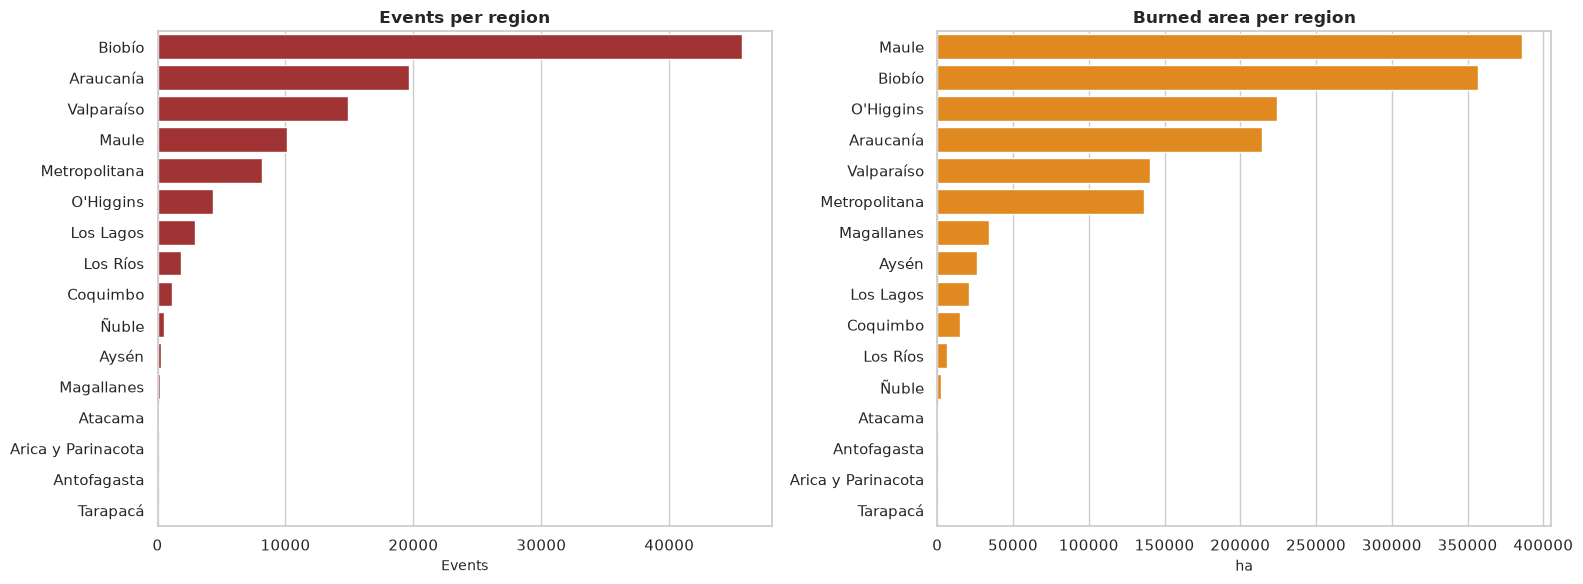

In [12]:
region_summary = (
	df.groupby("region")
	.agg(
		eventos=("region", "size"),
		superficie_total_ha=("superficie_total_ha", "sum"),
		superficie_mediana_ha=("superficie_total_ha", "median"),
		comunas=("comuna", "nunique"),
	)
	.sort_values("eventos", ascending=False)
)
display(region_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "comunas": "{:,}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=region_summary.reset_index(), x="eventos", y="region", ax=axes[0], color="firebrick")
axes[0].set_title("Events per region")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("")
sns.barplot(data=region_summary.sort_values("superficie_total_ha", ascending=False).reset_index(), x="superficie_total_ha", y="region", ax=axes[1], color="darkorange")
axes[1].set_title("Burned area per region")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

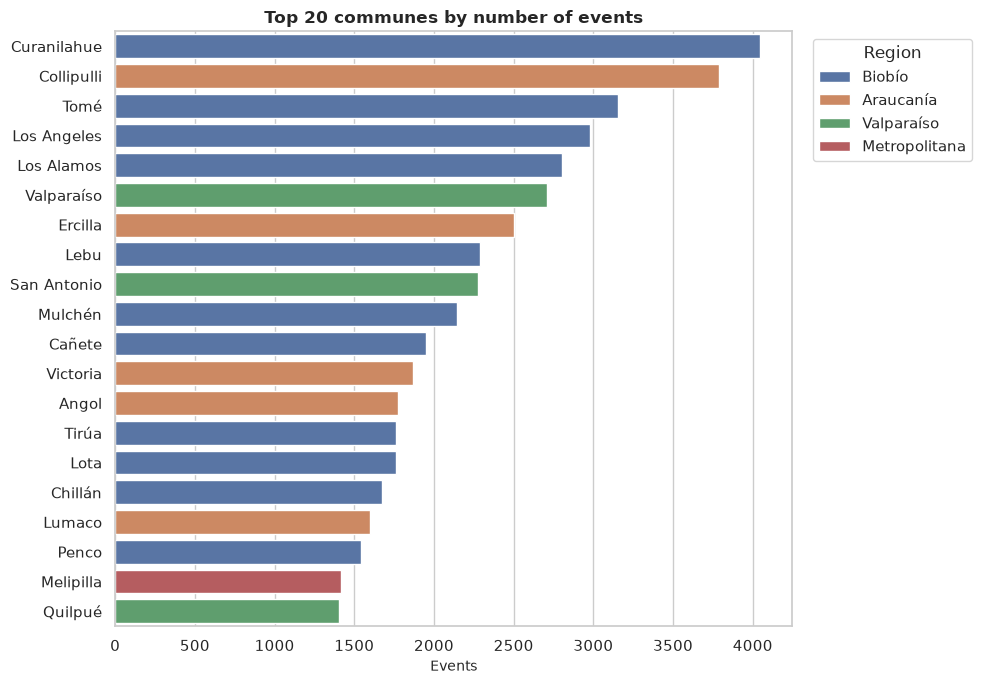

In [13]:
commune_summary = (
	df.groupby(["region", "provincia", "comuna"])
	.agg(eventos=("comuna", "size"), superficie_total_ha=("superficie_total_ha", "sum"))
	.sort_values("eventos", ascending=False)
)
display(commune_summary.head(20).style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}"}))

top_communes = commune_summary.head(20).reset_index()
plt.figure(figsize=(10, 7))
sns.barplot(data=top_communes, x="eventos", y="comuna", hue="region", dodge=False)
plt.title("Top 20 communes by number of events")
plt.xlabel("Events")
plt.ylabel("")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

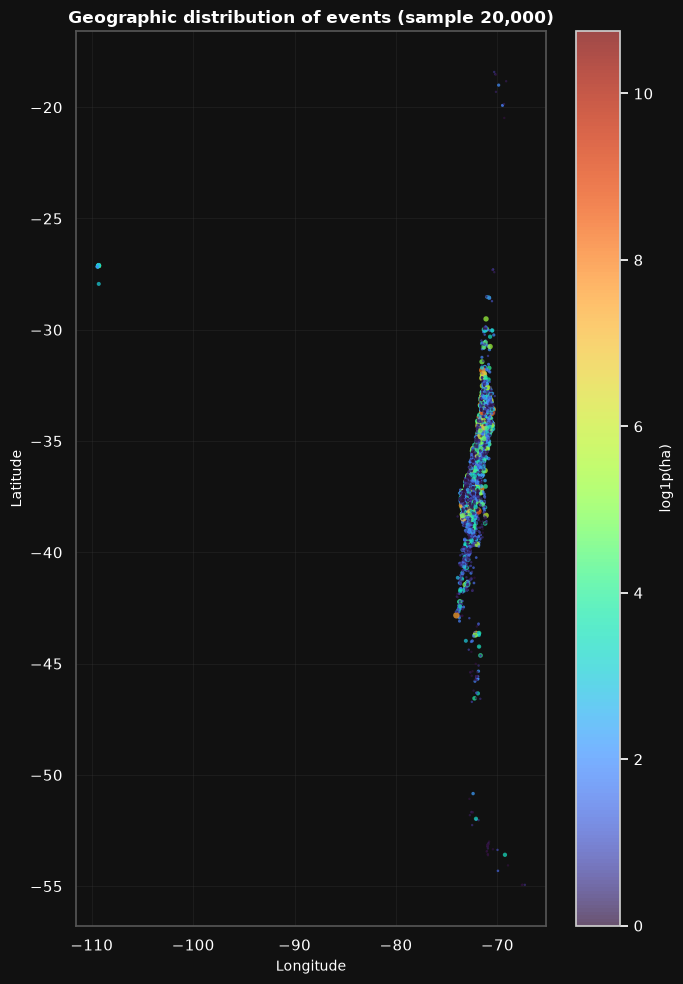

In [14]:
geo = df[["latitud", "longitud", "superficie_total_ha"]].dropna()
geo_sample = geo.sample(min(20_000, len(geo)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 10), facecolor="#111111")
ax.set_facecolor("#111111")
scatter = ax.scatter(
	geo_sample["longitud"],
	geo_sample["latitud"],
	s=np.clip(np.log1p(geo_sample["superficie_total_ha"]) * 2.8, 3, 44),
	c=np.log1p(geo_sample["superficie_total_ha"]),
	cmap="turbo",
	alpha=0.72,
	linewidths=0,
)
cbar = fig.colorbar(scatter, ax=ax, label="log1p(ha)")
cbar.ax.yaxis.label.set_color("white")
cbar.ax.tick_params(colors="white")
ax.set_title(f"Geographic distribution of events (sample {len(geo_sample):,})", color="white")
ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
	spine.set_color("#555555")
ax.grid(color="#333333", linewidth=0.5, alpha=0.5)
plt.tight_layout()

## 7. Alerts, scenarios and causes

In [15]:
alert_summary = categorical_summary(df, "alerta")
scenario_summary = categorical_summary(df, "escenario")
cause_summary = categorical_summary(df, "causa")

display(alert_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))
display(scenario_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))

,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
alerta,,,,
Sin alerta,"108,873","1,007,024.4",0.30,99.0%
Alerta roja,726,"521,012.7",25.30,0.7%
Alerta amarilla,348,"34,832.9",13.49,0.3%


,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
escenario,,,,
No definido,"86,387","767,005.2",0.27,78.6%
IFor-Vn,"12,336","230,805.1",0.60,11.2%
IFIUr-Fo,"7,265","104,917.1",0.33,6.6%
IFor-PI,"3,225","441,030.1",1.20,2.9%
IFCo,284,"9,260.9",1.58,0.3%
IFCSo,244,"5,459.1",1.92,0.2%
IFIns,91,"1,475.3",5.00,0.1%
IFASP,68,"2,791.6",0.23,0.1%
IFSu,47,125.5,0.50,0.0%


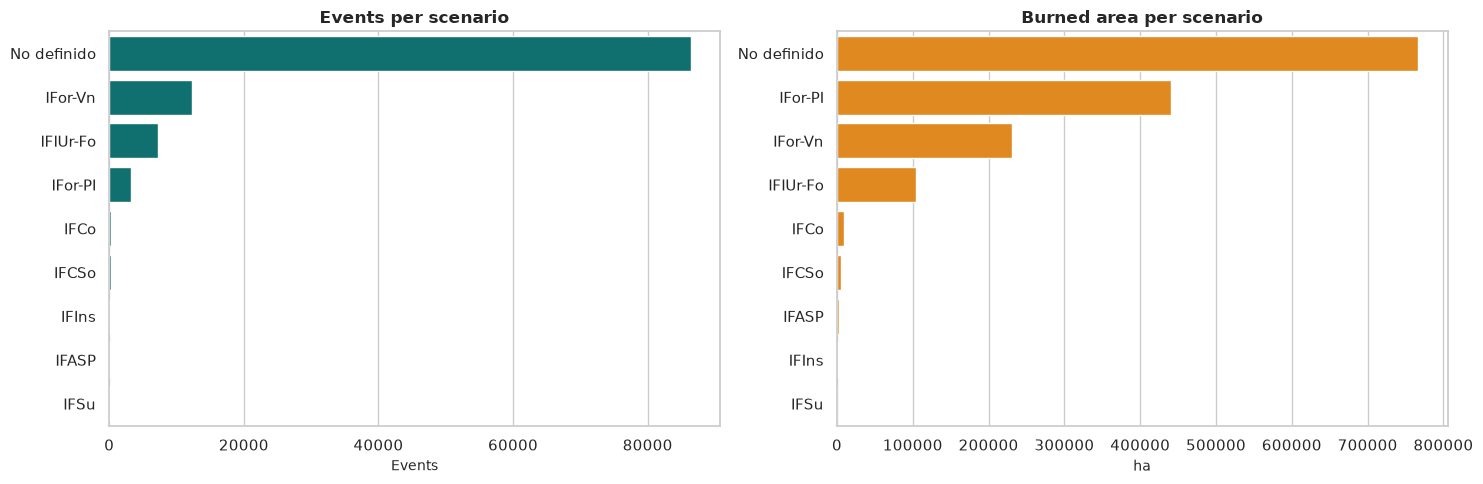

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=scenario_summary.reset_index(), x="eventos", y="escenario", ax=axes[0], color="teal")
axes[0].set_title("Events per scenario")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("")
sns.barplot(data=scenario_summary.sort_values("superficie_total_ha", ascending=False).reset_index(), x="superficie_total_ha", y="escenario", ax=axes[1], color="darkorange")
axes[1].set_title("Burned area per scenario")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
causa,,,,
Incendios intencionales,"36,117","463,117.8",0.18,32.8%
Tránsito de personasvehículos o aeronaves,"32,889","275,274.7",0.40,29.9%
Incendios de causa desconocida,"9,918","292,445.3",0.32,9.0%
Actividades recreativas,"7,108","68,206.0",0.30,6.5%
Faenas agrícolas y pecuarias,"4,638","80,213.0",1.00,4.2%
Faenas forestales,"4,492","30,184.8",0.50,4.1%
Quema de desechos,"4,313","40,830.5",0.40,3.9%
No definida,"3,711","35,935.5",0.15,3.4%
Accidentes eléctricos,"2,520","167,328.8",0.53,2.3%


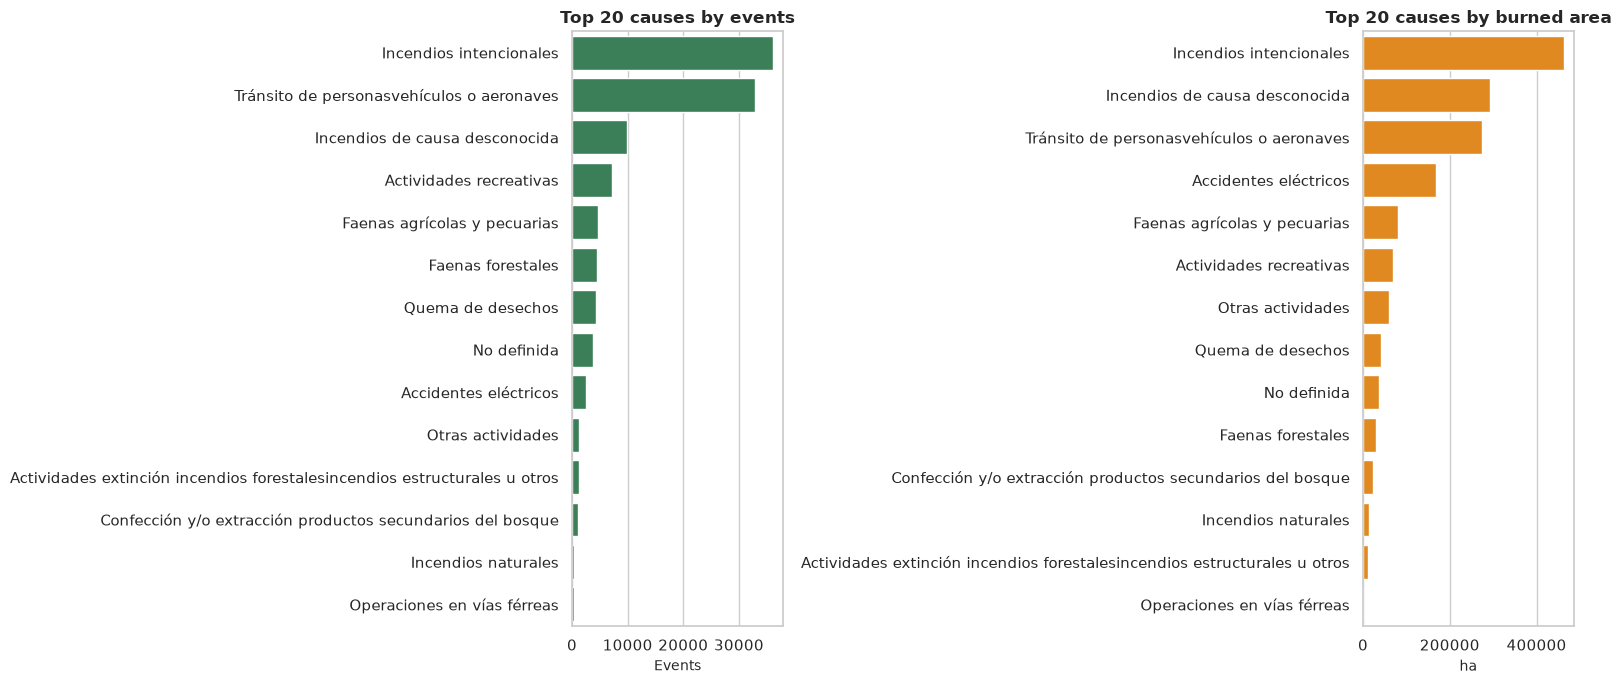

In [17]:
top_causes_events = cause_summary.head(20)
top_causes_surface = cause_summary.sort_values("superficie_total_ha", ascending=False).head(20)

display(top_causes_events.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top_causes_events.reset_index(), x="eventos", y="causa", ax=axes[0], color="seagreen")
axes[0].set_title("Top 20 causes by events")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("")
sns.barplot(data=top_causes_surface.reset_index(), x="superficie_total_ha", y="causa", ax=axes[1], color="darkorange")
axes[1].set_title("Top 20 causes by burned area")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

- For the purposes of this study, the causes of the fires are not relevant.

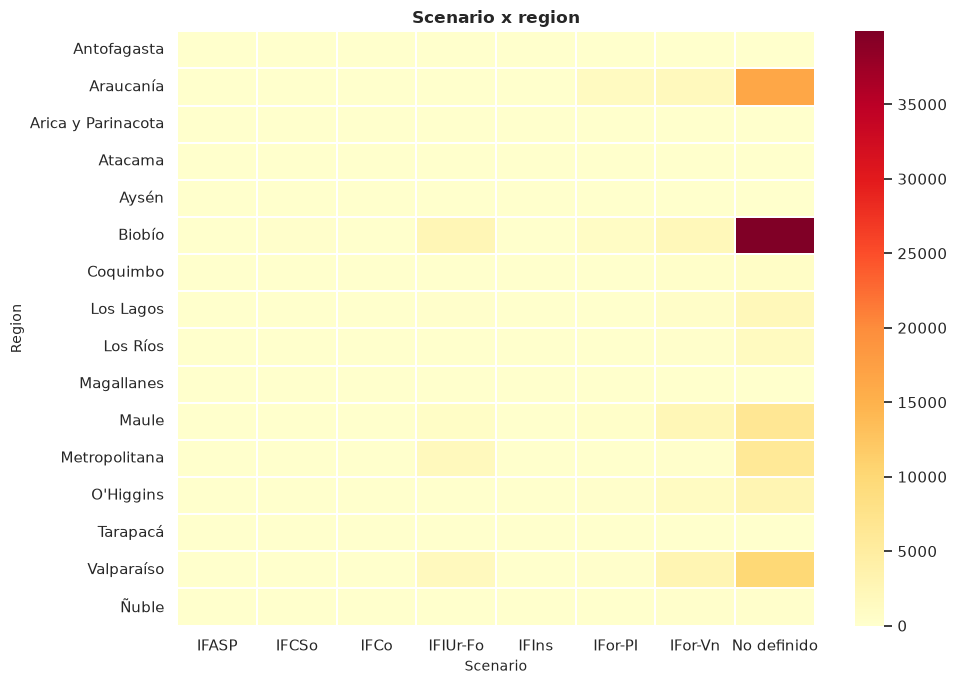

In [18]:
top_scenarios = scenario_summary.head(8).index
scenario_region = pd.crosstab(
	df.loc[df["escenario"].isin(top_scenarios), "region"],
	df.loc[df["escenario"].isin(top_scenarios), "escenario"],
)
plt.figure(figsize=(10, 7))
sns.heatmap(scenario_region, cmap="YlOrRd", linewidths=0.2)
plt.title("Scenario x region")
plt.xlabel("Scenario")
plt.ylabel("Region")
plt.tight_layout()

## 8. Burned area

,superficie_total_ha
count,"109,777.00"
mean,14.24
std,562.73
min,0.00
50%,0.30
75%,1.50
90%,5.50
95%,15.60
99%,154.43
max,"159,812.58"


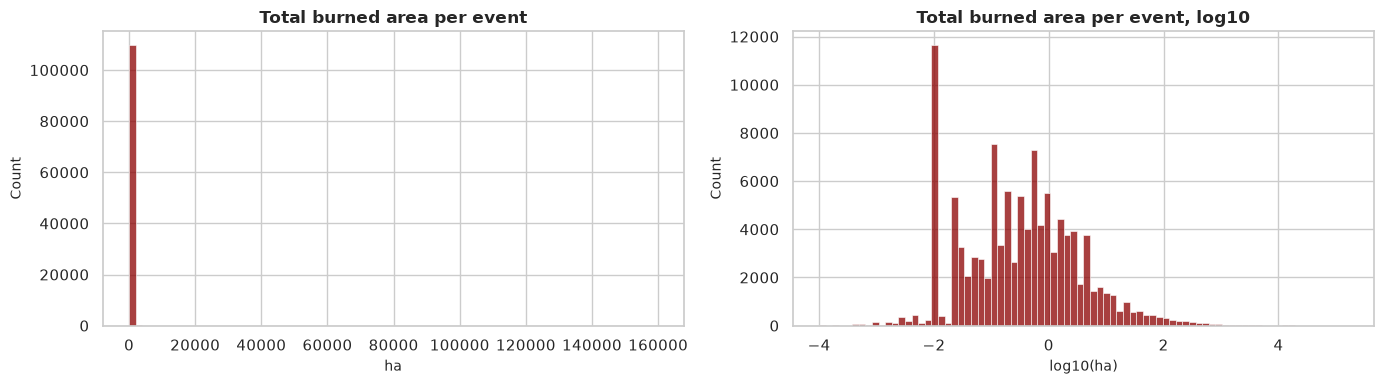

In [19]:
sup_pos = df.loc[df["superficie_total_ha"] > 0, "superficie_total_ha"]
surface_stats = sup_pos.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("superficie_total_ha")
display(surface_stats.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(sup_pos, bins=80, ax=axes[0], color="darkred")
axes[0].set_title("Total burned area per event")
axes[0].set_xlabel("ha")
sns.histplot(np.log10(sup_pos), bins=80, ax=axes[1], color="darkred")
axes[1].set_title("Total burned area per event, log10")
axes[1].set_xlabel("log10(ha)")
plt.tight_layout()

### Non-cumulative power-law fit

A non-cumulative distribution of burned area is estimated using logarithmic bins. The fit uses the tail of the distribution (`A >= p90`) and assumes:

`p(A) ~ A^{-beta}`

where `A` is the fire magnitude in hectares and `beta` is the negative of the log-log slope.

In [20]:
positive_surface = sup_pos.dropna().astype(float)

log_bin_edges = make_log_bins(positive_surface)
counts, edges = np.histogram(positive_surface, bins=log_bin_edges)
bin_widths = np.diff(edges)
bin_centers = np.sqrt(edges[:-1] * edges[1:])
noncumulative_density = counts / (counts.sum() * bin_widths)
plot_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0)

tail_xmin = positive_surface.quantile(POWER_LAW_QUANTILES[0])
fit_mask = plot_mask & (bin_centers >= tail_xmin)
if fit_mask.sum() < 3:
	tail_xmin = positive_surface.quantile(POWER_LAW_QUANTILES[1])
	fit_mask = plot_mask & (bin_centers >= tail_xmin)

log_bin_centers = np.log10(bin_centers[fit_mask])
log_density = np.log10(noncumulative_density[fit_mask])
slope, intercept = np.polyfit(log_bin_centers, log_density, 1)
power_law_beta = -slope
pred_log_density = intercept + slope * log_bin_centers
ss_res = np.sum((log_density - pred_log_density) ** 2)
ss_tot = np.sum((log_density - log_density.mean()) ** 2)
power_law_r2 = 1 - ss_res / ss_tot if ss_tot else np.nan

power_law_summary = pd.DataFrame(
	{
		"metric": ["beta", "log-log slope", "intercept", "fit xmin (ha)", "bins used", "events in tail", "R2 log-log"],
		"value": [
			power_law_beta, slope, intercept, tail_xmin,
			int(fit_mask.sum()), int(counts[fit_mask].sum()), power_law_r2,
		],
	}
)
display(power_law_summary.style.format({"value": "{:,.3f}"}))

,metric,value
0,beta,1.878
1,log-log slope,-1.878
2,intercept,-0.285
3,fit xmin (ha),5.500
4,bins used,23.000
5,events in tail,"12,547.000"
6,R2 log-log,0.994


In [21]:
pareto_sup_sorted = positive_surface.sort_values(ascending=False).reset_index(drop=True)
pareto_total_area = pareto_sup_sorted.sum()
pareto_total_events = len(pareto_sup_sorted)
pareto_cum_area_share = pareto_sup_sorted.cumsum() / pareto_total_area
pareto_cum_event_share = (np.arange(pareto_total_events) + 1) / pareto_total_events

pareto_events_for_80 = int((pareto_cum_area_share >= 0.80).idxmax() + 1)
pareto_event_share_for_80 = pareto_events_for_80 / pareto_total_events
pareto_top_20_events = max(1, int(np.ceil(pareto_total_events * 0.20)))
pareto_area_share_top_20 = pareto_sup_sorted.iloc[:pareto_top_20_events].sum() / pareto_total_area

pareto_summary = pd.DataFrame(
	{
		"metric": [
			"events with positive area",
			"events for 80% of area",
			"% events for 80%",
			"area explained by top 20% events",
		],
		"value": [pareto_total_events, pareto_events_for_80, pareto_event_share_for_80, pareto_area_share_top_20],
	}
)
display(
	pareto_summary.style.format(
		{
			"value": lambda value: f"{value:,.0f}" if value >= 1 else f"{value:.2%}",
		}
	)
)

,metric,value
0,events with positive area,"109,777"
1,events for 80% of area,"1,240"
2,% events for 80%,1.13%
3,area explained by top 20% events,97.75%


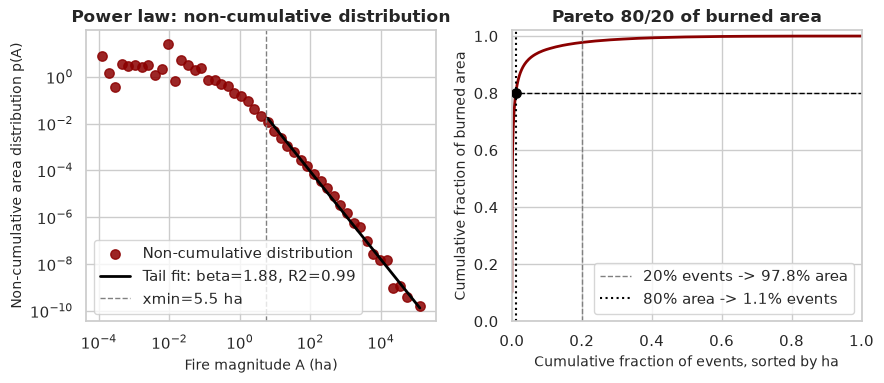

In [22]:
fit_surface_range = np.logspace(log_bin_centers.min(), log_bin_centers.max(), 100)
fit_density_curve = 10 ** (intercept + slope * np.log10(fit_surface_range))

fig, axes = plt.subplots(1, 2, figsize=(9,4 ))

axes[0].scatter(
	bin_centers[plot_mask],
	noncumulative_density[plot_mask],
	s=46,
	alpha=0.85,
	color="darkred",
	label="Non-cumulative distribution",
)
axes[0].plot(
	fit_surface_range,
	fit_density_curve,
	color="black",
	linewidth=2,
	label=f"Tail fit: beta={power_law_beta:.2f}, R2={power_law_r2:.2f}",
)
axes[0].axvline(tail_xmin, color="gray", linestyle="--", linewidth=1, label=f"xmin={tail_xmin:.1f} ha")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Power law: non-cumulative distribution")
axes[0].set_xlabel("Fire magnitude A (ha)")
axes[0].set_ylabel("Non-cumulative area distribution p(A)")
axes[0].legend()

axes[1].plot(pareto_cum_event_share, pareto_cum_area_share, color="darkred", linewidth=2)
axes[1].axvline(0.20, color="gray", linestyle="--", linewidth=1, label=f"20% events -> {pareto_area_share_top_20:.1%} area")
axes[1].axhline(0.80, color="black", linestyle="--", linewidth=1)
axes[1].axvline(pareto_event_share_for_80, color="black", linestyle=":", linewidth=1.5, label=f"80% area -> {pareto_event_share_for_80:.1%} events")
axes[1].scatter([pareto_event_share_for_80], [0.80], color="black", s=45, zorder=3)
axes[1].set_title("Pareto 80/20 of burned area")
axes[1].set_xlabel("Cumulative fraction of events, sorted by ha")
axes[1].set_ylabel("Cumulative fraction of burned area")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()

### Betas per scenario

The non-cumulative fit is repeated per `escenario`. For numerical stability, each scenario first tries to fit the `p90` tail; if fewer than 5 positive bins remain, it relaxes to `p75` and then `p50`. Scenarios with few events should be read with caution, even if the fit yields a high `R2`.

In [23]:
scenario_rows = []
for escenario, group in df.groupby("escenario"):
	fit = fit_noncumulative_power_law(group["superficie_total_ha"])
	if fit is None:
		scenario_rows.append(
			{
				"escenario": escenario,
				"eventos_positivos": int((group["superficie_total_ha"] > 0).sum()),
				"beta": np.nan,
				"pendiente": np.nan,
				"intercepto": np.nan,
				"xmin_ha": np.nan,
				"cola_usada": "insufficient",
				"bins_usados": 0,
				"eventos_en_cola": 0,
				"r2_log_log": np.nan,
			}
		)
		continue
	fit["escenario"] = escenario
	scenario_rows.append(fit)

scenario_power_law = pd.DataFrame(scenario_rows).sort_values("beta").reset_index(drop=True)
scenario_power_law["soporte"] = np.where(
	scenario_power_law["eventos_positivos"] >= PARETO_THRESHOLD_HIGH,
	"high",
	np.where(scenario_power_law["eventos_positivos"] >= PARETO_THRESHOLD_MED, "medium", "low"),
)
scenario_power_law_valid = scenario_power_law.dropna(subset=["beta"]).copy()

display(
	scenario_power_law[
		[
			"escenario",
			"beta",
			"r2_log_log",
			"xmin_ha",
			"cola_usada",
			"bins_usados",
			"eventos_en_cola",
			"eventos_positivos",
			"soporte",
		]
	].style.format(
		{
			"beta": "{:.3f}",
			"r2_log_log": "{:.3f}",
			"xmin_ha": "{:,.2f}",
			"bins_usados": "{:,}",
			"eventos_en_cola": "{:,}",
			"eventos_positivos": "{:,}",
		}
	)
)

,escenario,beta,r2_log_log,xmin_ha,cola_usada,bins_usados,eventos_en_cola,eventos_positivos,soporte
0,IFASP,1.241,0.915,6.18,p75,5,19,68,low
1,IFSu,1.329,0.989,0.50,p50,5,21,47,low
2,IFCSo,1.527,0.871,36.47,p90,7,23,244,medium
3,IFor-PI,1.550,0.994,26.00,p90,21,322,"3,224",high
4,IFIUr-Fo,1.640,0.991,5.00,p90,23,797,"7,265",high
5,IFIns,1.652,0.943,5.00,p50,6,34,91,low
6,IFor-Vn,1.771,0.994,9.50,p90,21,"1,237","12,333",high
7,No definido,1.849,0.992,5.00,p90,21,"9,480","86,221",high
8,IFCo,2.200,0.914,71.40,p90,6,26,284,medium


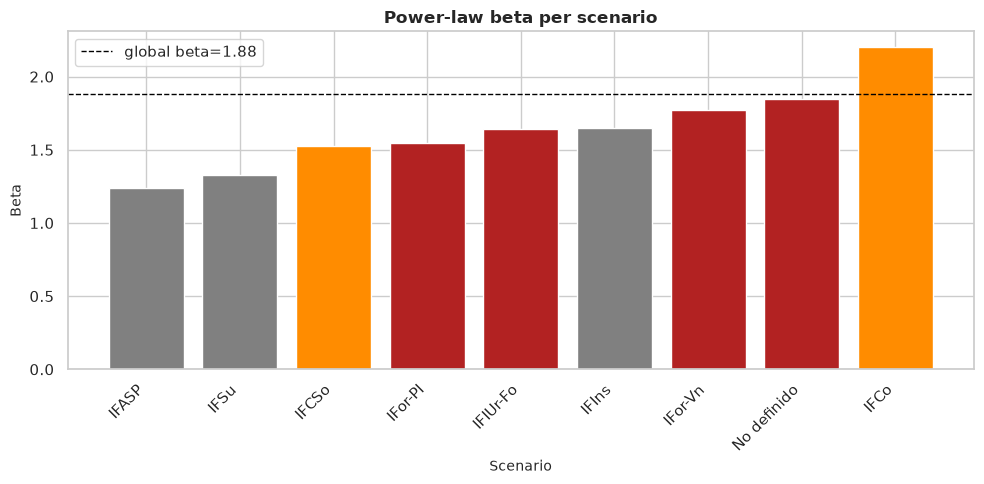

In [24]:
plt.figure(figsize=(10, 5))
bar_colors = scenario_power_law_valid["soporte"].map({"high": "firebrick", "medium": "darkorange", "low": "gray"})
plt.bar(scenario_power_law_valid["escenario"], scenario_power_law_valid["beta"], color=bar_colors)
plt.axhline(power_law_beta, color="black", linestyle="--", linewidth=1, label=f"global beta={power_law_beta:.2f}")
plt.title("Power-law beta per scenario")
plt.xlabel("Scenario")
plt.ylabel("Beta")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

,superficie_total_ha,pct_superficie
superficie_quemada_matorral_ha,"357,666.9",22.9%
superficie_quemada_pastizal_ha,"266,412.1",17.0%
superficie_quemada_arbolado_ha,"246,530.7",15.8%
superficie_quemada_pino_c_ha,"199,979.7",12.8%
superficie_quemada_eucalipto_ha,"145,474.9",9.3%
superficie_quemada_pino_a_ha,"112,891.9",7.2%
superficie_quemada_pino_b_ha,"89,069.0",5.7%
superficie_quemada_desechos_ha,"83,536.0",5.3%
superficie_quemada_agricola_ha,"53,332.8",3.4%
superficie_quemada_otras_plantas_ha,"7,975.9",0.5%


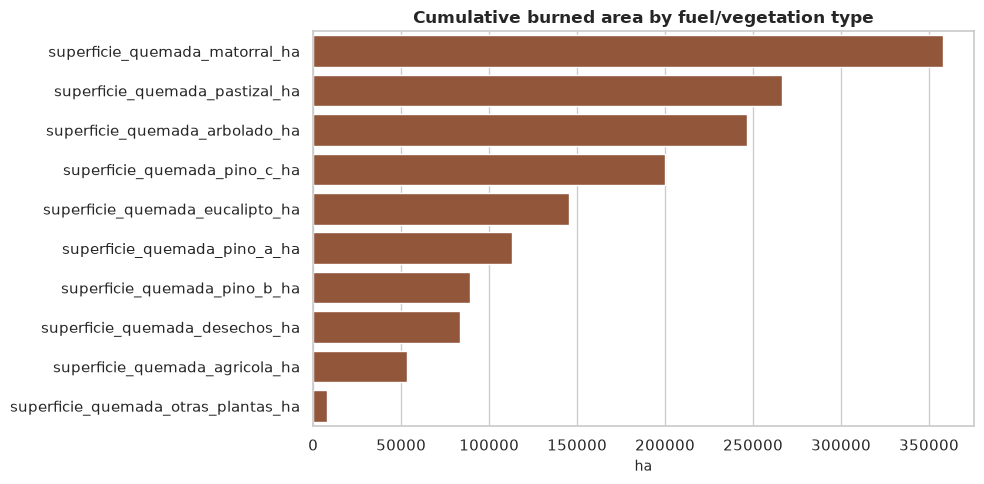

In [25]:
veg_totals = (
	df[VEG_COLS]
	.apply(pd.to_numeric, errors="coerce")
	.sum()
	.sort_values(ascending=False)
	.rename("superficie_total_ha")
	.to_frame()
)
veg_totals["pct_superficie"] = veg_totals["superficie_total_ha"] / veg_totals["superficie_total_ha"].sum()
display(veg_totals.style.format({"superficie_total_ha": "{:,.1f}", "pct_superficie": "{:.1%}"}))

plt.figure(figsize=(10, 5))
sns.barplot(data=veg_totals.reset_index(), x="superficie_total_ha", y="index", color="sienna")
plt.title("Cumulative burned area by fuel/vegetation type")
plt.xlabel("ha")
plt.ylabel("")
plt.tight_layout()

In [26]:
top_fires = (
	df.sort_values("superficie_total_ha", ascending=False)
	[["temporada", "fecha_hora_inicio", "region", "provincia", "comuna", "nombre", "alerta", "escenario", "causa", "superficie_total_ha", "duracion_minutos"]]
	.head(20)
)
display(top_fires.style.format({"superficie_total_ha": "{:,.1f}", "duracion_minutos": "{:,.0f}"}))

,temporada,fecha_hora_inicio,region,provincia,comuna,nombre,alerta,escenario,causa,superficie_total_ha,duracion_minutos
85090,2016-2017,2017-01-20 22:01:00,Maule,Cauquenes,Cauquenes,LAS MÁQUINAS,Alerta roja,IFor-PI,Incendios de causa desconocida,"159,812.6",776
84536,2016-2017,2017-01-17 16:35:00,O'Higgins,Colchagua,Pumanque,NILAHUE BARAHONA,Alerta roja,IFor-PI,Accidentes eléctricos,"46,490.0",85
85059,2016-2017,2017-01-14 23:00:00,Maule,Curicó,Vichuquén,LAS CARDILLAS,Alerta roja,IFor-PI,Incendios intencionales,"37,308.1",628
86782,2016-2017,2017-01-20 22:33:00,Biobío,Concepción,Florida,SAN ANTONIO,Alerta roja,IFor-Vn,Incendios intencionales,"30,391.1","1,243"
54731,2011-2012,2011-12-30 02:37:00,Biobío,Concepción,Florida,PICHIQUEIME,Sin alerta,No definido,Incendios intencionales,"24,895.7",855
56121,2011-2012,2011-12-27 18:47:00,Magallanes,Ultima Esperanza,Torres del Paine,RIO OLGUIN,Sin alerta,No definido,Tránsito de personasvehículos o aeronaves,"17,606.3",238
19381,2004-2005,2005-02-17 12:55:00,Magallanes,Ultima Esperanza,Torres del Paine,LAGUNA AZUL,Sin alerta,No definido,No definida,"15,470.0","-1,000,000"
86849,2016-2017,2017-01-25 15:20:00,Biobío,Concepción,Concepción,CASERIO CHAIMAVIDA,Sin alerta,IFor-PI,Incendios intencionales,"15,204.7","1,434"
101158,2018-2019,2019-02-04 19:40:00,Aysén,Capitán Prat,Cochrane,COLONIA SUR,Alerta roja,IFor-Vn,Quema de desechos,"15,145.0",875
103140,2019-2020,2020-02-09 16:26:00,Maule,Curicó,Molina,AGUA FRIA,Alerta roja,IFor-PI,Incendios intencionales,"14,987.9",50


## 9. Duration

,duracion_minutos
count,"108,442.00"
mean,289.05
std,361.38
min,1.00
50%,132.00
75%,302.00
90%,984.00
95%,"1,220.00"
99%,"1,392.00"
max,"1,439.00"


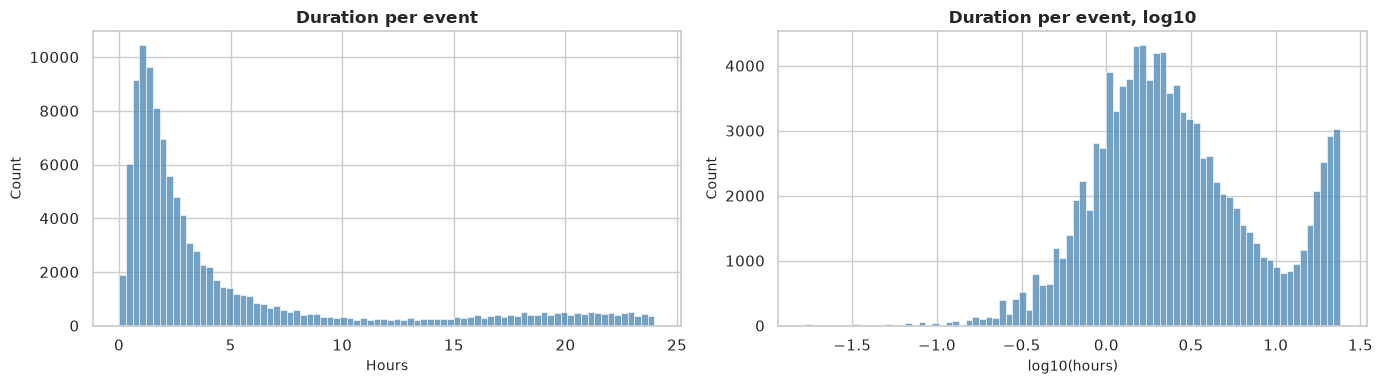

In [27]:
duration_pos = df.loc[df["duracion_minutos"] > 0, "duracion_minutos"]
duration_stats = duration_pos.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("duracion_minutos")
display(duration_stats.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(duration_pos / 60, bins=80, ax=axes[0], color="steelblue")
axes[0].set_title("Duration per event")
axes[0].set_xlabel("Hours")
sns.histplot(np.log10(duration_pos / 60), bins=80, ax=axes[1], color="steelblue")
axes[1].set_title("Duration per event, log10")
axes[1].set_xlabel("log10(hours)")
plt.tight_layout()

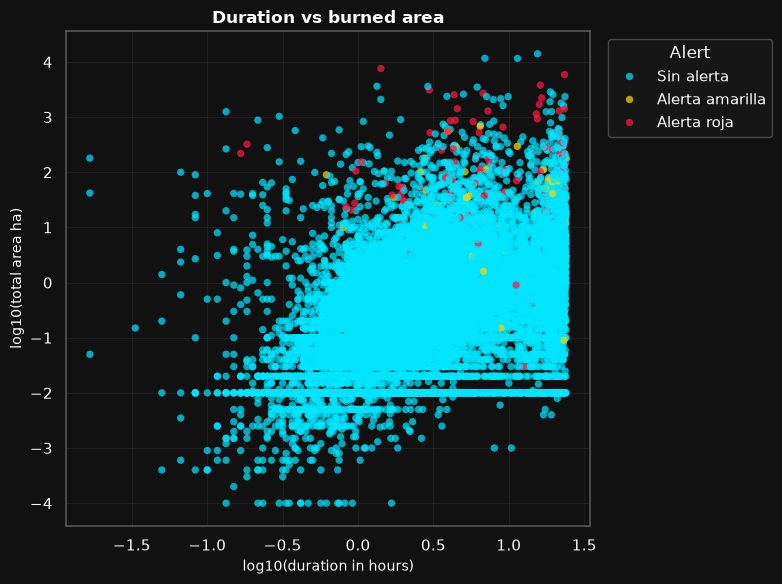

In [28]:
rel = df[(df["duracion_horas"] > 0) & (df["superficie_total_ha"] > 0)].copy()
rel_sample = rel.sample(min(20_000, len(rel)), random_state=42)

alert_palette = {
	"Sin alerta": "#00E5FF",
	"Alerta amarilla": "#FFD400",
	"Alerta roja": "#FF1744",
}

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#111111")
ax.set_facecolor("#111111")
sns.scatterplot(
	data=rel_sample,
	x=np.log10(rel_sample["duracion_horas"]),
	y=np.log10(rel_sample["superficie_total_ha"]),
	hue="alerta",
	palette=alert_palette,
	alpha=0.72,
	s=28,
	linewidth=0,
	ax=ax,
)
ax.set_title("Duration vs burned area", color="white")
ax.set_xlabel("log10(duration in hours)", color="white")
ax.set_ylabel("log10(total area ha)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
	spine.set_color("#555555")
ax.grid(color="#333333", linewidth=0.5, alpha=0.55)
legend = ax.legend(title="Alert", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
legend.get_frame().set_facecolor("#181818")
legend.get_frame().set_edgecolor("#555555")
legend.get_title().set_color("white")
for text in legend.get_texts():
	text.set_color("white")
plt.tight_layout()

## 11. Focal analysis: key scenarios in central-southern regions

The dataset is filtered to the 4 scenarios of greatest operational relevance (`IFor-PI`, `IFor-Vn`, `IFIUr-Fo`, `No definido`) in the 4 regions with the highest historical wildfire activity in Chile (Maule, Biobio, Araucania, O'Higgins).

In [29]:
FOCUS_SCENARIOS = ["IFor-PI", "IFor-Vn", "IFIUr-Fo", "No definido"]
FOCUS_REGIONS = ["Maule", "Biobío", "Araucanía", "O'Higgins"]

df_focus = df[
	df["escenario"].isin(FOCUS_SCENARIOS) &
	df["region"].isin(FOCUS_REGIONS)
].copy()

print(f"Records in subset: {len(df_focus):,} of {len(df):,} ({len(df_focus)/len(df):.1%})")
print(f"Scenarios present: {sorted(df_focus['escenario'].unique())}")
print(f"Regions present:   {sorted(df_focus['region'].unique())}")

Records in subset: 79,340 of 109,947 (72.2%)
Scenarios present: ['IFIUr-Fo', 'IFor-PI', 'IFor-Vn', 'No definido']
Regions present:   ['Araucanía', 'Biobío', 'Maule', "O'Higgins"]


,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
escenario,,,,
No definido,"65,616","541,175.0",0.23,82.7%
IFor-Vn,"7,637","166,858.3",0.80,9.6%
IFIUr-Fo,"3,285","19,392.0",0.30,4.1%
IFor-PI,"2,802","438,409.9",1.40,3.5%


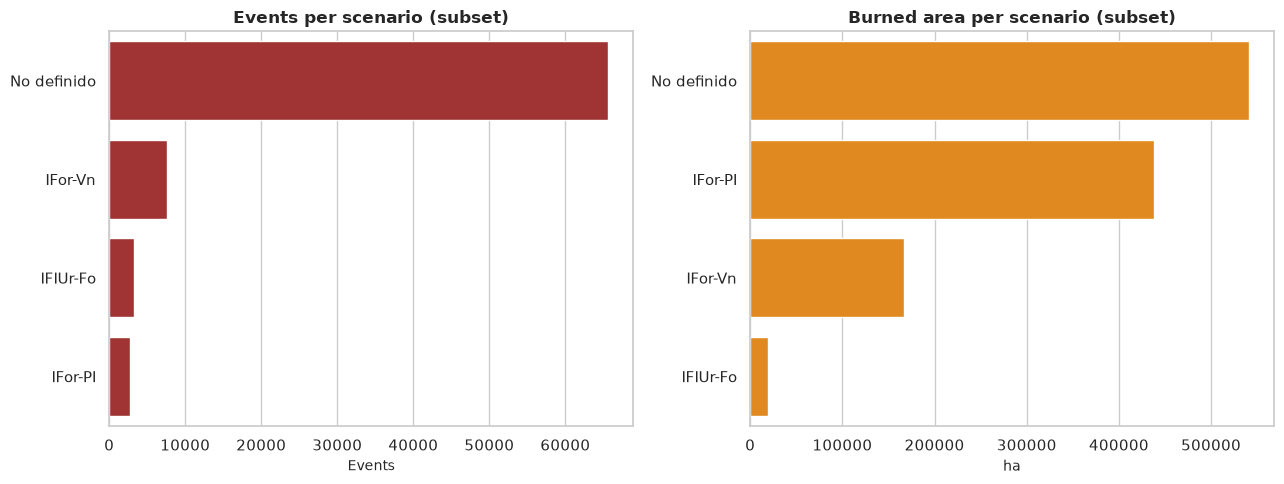

In [30]:
focus_scenario_summary = categorical_summary(df_focus, "escenario")
display(
	focus_scenario_summary.style.format(
		{
			"eventos": "{:,}",
			"superficie_total_ha": "{:,.1f}",
			"superficie_mediana_ha": "{:,.2f}",
			"pct_eventos": "{:.1%}",
		}
	)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
	data=focus_scenario_summary.reset_index(),
	x="eventos", y="escenario",
	ax=axes[0], color="firebrick",
)
axes[0].set_title("Events per scenario (subset)")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("")
sns.barplot(
	data=focus_scenario_summary.sort_values("superficie_total_ha", ascending=False).reset_index(),
	x="superficie_total_ha", y="escenario",
	ax=axes[1], color="darkorange",
)
axes[1].set_title("Burned area per scenario (subset)")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

escenario,IFIUr-Fo,IFor-PI,IFor-Vn,No definido
region,,,,
Araucanía,49,"1,285","1,816","16,426"
Biobío,"2,521",895,"2,142","39,902"
Maule,649,427,"2,486","6,403"
O'Higgins,66,195,"1,193","2,885"


escenario,IFIUr-Fo,IFor-PI,IFor-Vn,No definido
region,,,,
Araucanía,"3,654.7","48,951.3","25,050.5","133,342.5"
Biobío,"8,552.6","53,449.4","83,748.1","205,703.9"
Maule,"6,774.7","250,981.3","23,249.1","99,045.8"
O'Higgins,410.1,"85,027.8","34,810.6","103,082.7"


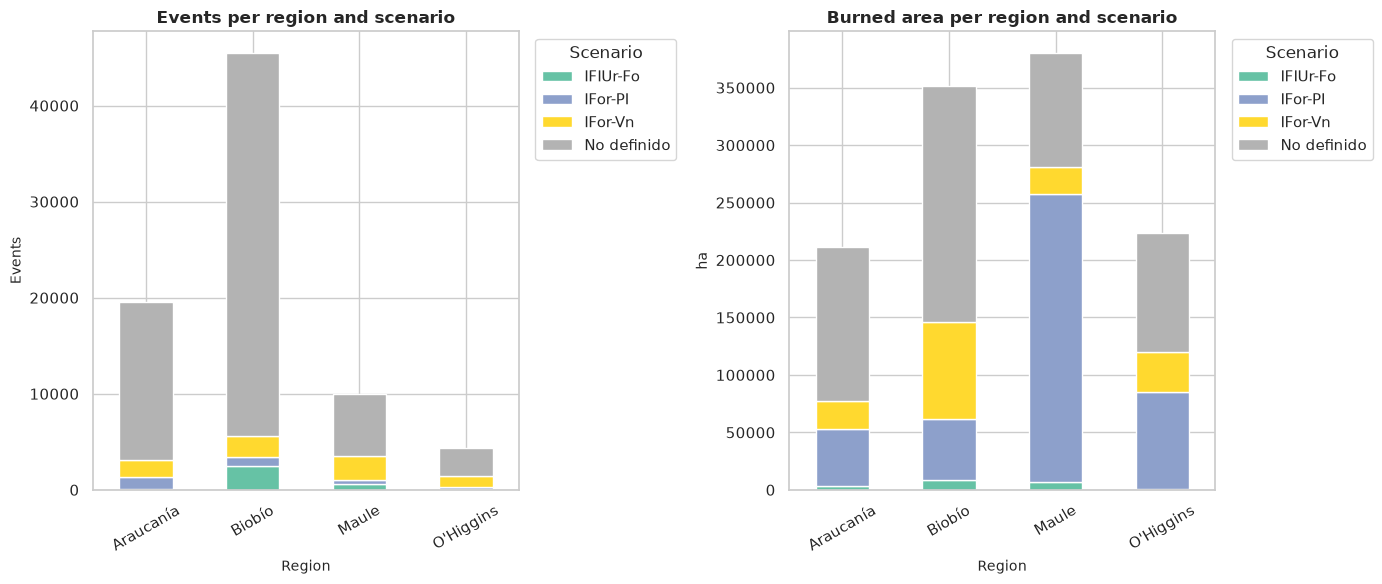

In [31]:
events_pivot = df_focus.groupby(["region", "escenario"]).size().unstack(fill_value=0)
ha_pivot = (
	df_focus.groupby(["region", "escenario"])["superficie_total_ha"]
	.sum()
	.unstack(fill_value=0)
)
display(events_pivot.style.format("{:,}"))
display(ha_pivot.style.format("{:,.1f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
events_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Events per region and scenario")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Events")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc="upper left")
ha_pivot.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Burned area per region and scenario")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("ha")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

,metric,value
0,events with positive area,"79,285"
1,events for 80% of area,730
2,% events for 80%,0.92%
3,area explained by top 20% events,98.03%


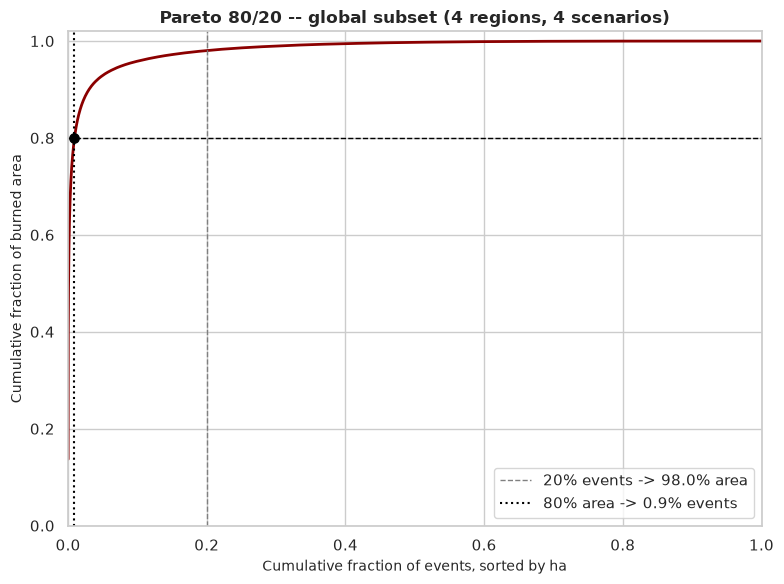

In [32]:
focus_surface = df_focus.loc[df_focus["superficie_total_ha"] > 0, "superficie_total_ha"]
focus_sorted = focus_surface.sort_values(ascending=False).reset_index(drop=True)
focus_total_events = len(focus_sorted)
focus_cum_area = focus_sorted.cumsum() / focus_sorted.sum()
focus_cum_events = (np.arange(focus_total_events) + 1) / focus_total_events

focus_events_for_80 = int((focus_cum_area >= 0.80).idxmax() + 1)
focus_event_share_for_80 = focus_events_for_80 / focus_total_events
focus_top_20 = max(1, int(np.ceil(focus_total_events * 0.20)))
focus_area_top_20 = focus_sorted.iloc[:focus_top_20].sum() / focus_sorted.sum()

focus_pareto_summary = pd.DataFrame(
	{
		"metric": [
			"events with positive area",
			"events for 80% of area",
			"% events for 80%",
			"area explained by top 20% events",
		],
		"value": [focus_total_events, focus_events_for_80, focus_event_share_for_80, focus_area_top_20],
	}
)
display(
	focus_pareto_summary.style.format(
		{"value": lambda v: f"{v:,.0f}" if v >= 1 else f"{v:.2%}"}
	)
)

plt.figure(figsize=(8, 6))
plt.plot(focus_cum_events, focus_cum_area, color="darkred", linewidth=2)
plt.axvline(0.20, color="gray", linestyle="--", linewidth=1,
	    label=f"20% events -> {focus_area_top_20:.1%} area")
plt.axhline(0.80, color="black", linestyle="--", linewidth=1)
plt.axvline(focus_event_share_for_80, color="black", linestyle=":", linewidth=1.5,
	    label=f"80% area -> {focus_event_share_for_80:.1%} events")
plt.scatter([focus_event_share_for_80], [0.80], color="black", s=45, zorder=3)
plt.title("Pareto 80/20 -- global subset (4 regions, 4 scenarios)")
plt.xlabel("Cumulative fraction of events, sorted by ha")
plt.ylabel("Cumulative fraction of burned area")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()

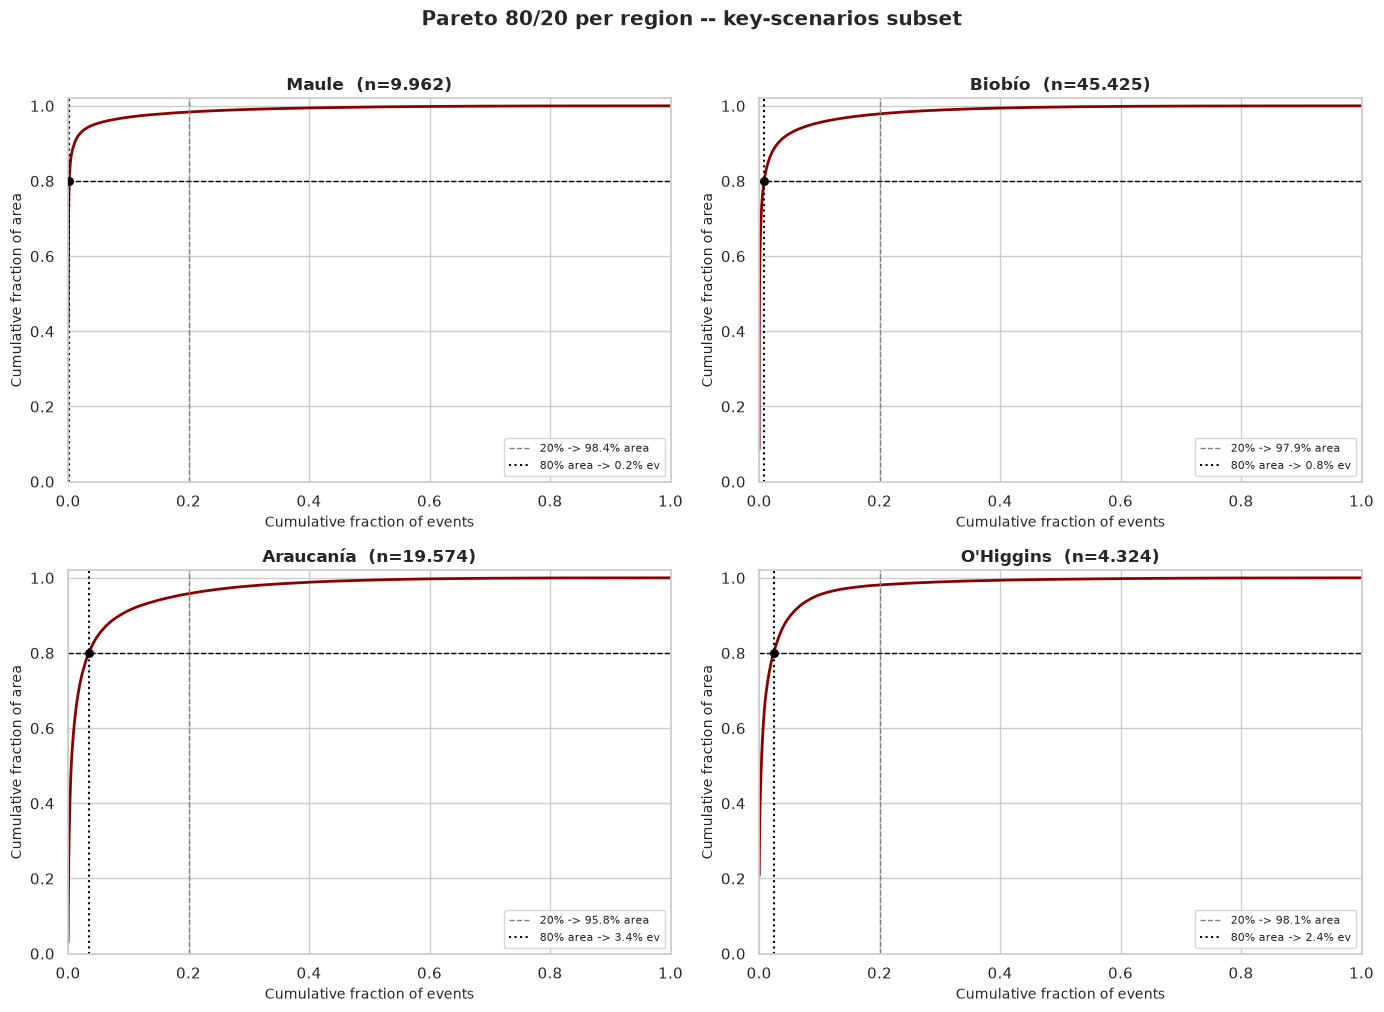

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, region in zip(axes.flat, FOCUS_REGIONS):
	region_surface = df_focus.loc[
		(df_focus["region"] == region) & (df_focus["superficie_total_ha"] > 0),
		"superficie_total_ha",
	]
	n = len(region_surface)
	if n == 0:
		ax.text(0.5, 0.5, f"{region}\nNo data", ha="center", va="center",
		        transform=ax.transAxes, fontsize=12)
		ax.set_title(region, fontweight="bold")
		continue

	sorted_s = region_surface.sort_values(ascending=False).reset_index(drop=True)
	cum_area = sorted_s.cumsum() / sorted_s.sum()
	cum_events = (np.arange(n) + 1) / n

	mask_80 = cum_area >= 0.80
	events_for_80 = int(mask_80.idxmax() + 1) if mask_80.any() else n
	event_share_for_80 = events_for_80 / n
	top_20 = max(1, int(np.ceil(n * 0.20)))
	area_top_20 = sorted_s.iloc[:top_20].sum() / sorted_s.sum()

	ax.plot(cum_events, cum_area, color="darkred", linewidth=2)
	ax.axvline(0.20, color="gray", linestyle="--", linewidth=1,
	           label=f"20% -> {area_top_20:.1%} area")
	ax.axhline(0.80, color="black", linestyle="--", linewidth=1)
	ax.axvline(event_share_for_80, color="black", linestyle=":", linewidth=1.5,
	           label=f"80% area -> {event_share_for_80:.1%} ev")
	ax.scatter([event_share_for_80], [0.80], color="black", s=30, zorder=3)
	ax.set_title(f"{region}  (n={fmt_int(n)})", fontweight="bold")
	ax.set_xlabel("Cumulative fraction of events")
	ax.set_ylabel("Cumulative fraction of area")
	ax.set_xlim(0, 1)
	ax.set_ylim(0, 1.02)
	ax.legend(fontsize=8)

plt.suptitle("Pareto 80/20 per region -- key-scenarios subset", fontweight="bold", y=1.01)
plt.tight_layout()

,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
causa,,,,
Incendios intencionales,"27,744","195,008.5",0.12,42.3%
Tránsito de personasvehículos o aeronaves,"13,001","69,629.5",0.40,19.8%
Incendios de causa desconocida,"7,687","89,250.4",0.30,11.7%
No definida,"3,198","6,504.3",0.14,4.9%
Actividades recreativas,"2,923","14,042.5",0.40,4.5%
Faenas forestales,"2,556","12,909.6",0.40,3.9%
Faenas agrícolas y pecuarias,"2,490","40,126.8",1.01,3.8%
Quema de desechos,"2,191","9,048.4",0.30,3.3%
Accidentes eléctricos,"1,308","56,530.5",0.50,2.0%


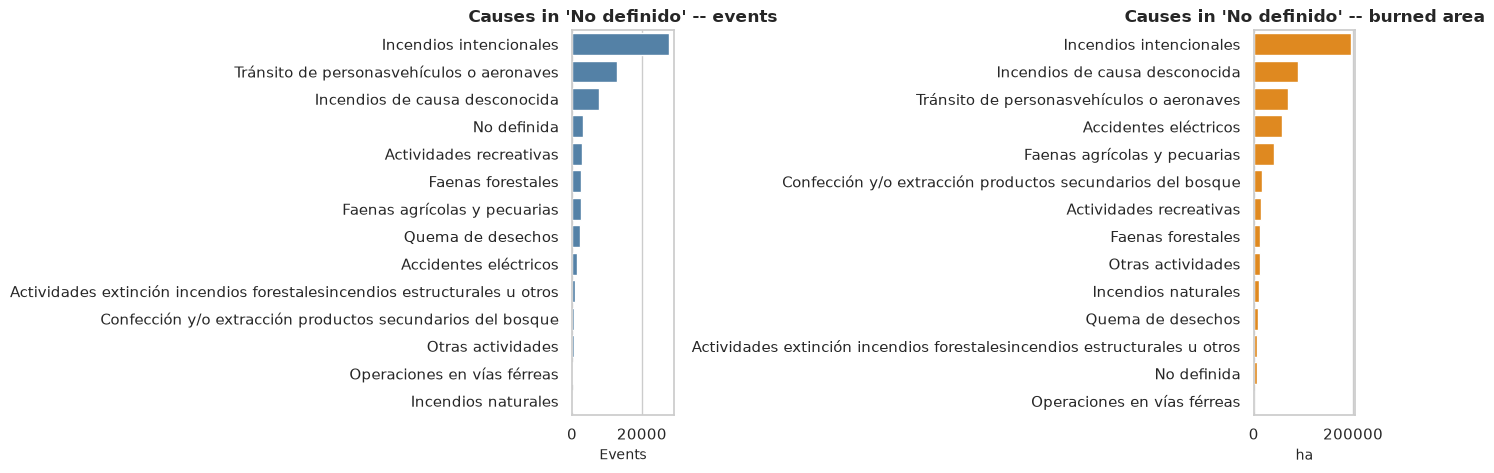

In [34]:
no_definido = df_focus[df_focus["escenario"] == "No definido"].copy()
no_def_causes = (
	no_definido.groupby("causa")
	.agg(
		eventos=("causa", "size"),
		superficie_total_ha=("superficie_total_ha", "sum"),
		superficie_mediana_ha=("superficie_total_ha", "median"),
	)
	.assign(pct_eventos=lambda x: x["eventos"] / len(no_definido))
	.sort_values("eventos", ascending=False)
)
display(
	no_def_causes.style.format(
		{
			"eventos": "{:,}",
			"superficie_total_ha": "{:,.1f}",
			"superficie_mediana_ha": "{:,.2f}",
			"pct_eventos": "{:.1%}",
		}
	)
)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(no_def_causes) * 0.35)))
sns.barplot(data=no_def_causes.reset_index(), x="eventos", y="causa", ax=axes[0], color="steelblue")
axes[0].set_title("Causes in 'No definido' -- events")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("")
sns.barplot(
	data=no_def_causes.sort_values("superficie_total_ha", ascending=False).reset_index(),
	x="superficie_total_ha", y="causa", ax=axes[1], color="darkorange",
)
axes[1].set_title("Causes in 'No definido' -- burned area")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

## 10. Conclusions

In [35]:
top_season_events = season_summary["eventos"].idxmax()
top_season_surface = season_summary["superficie_total_ha"].idxmax()
top_region_events = region_summary["eventos"].idxmax()
top_region_surface = region_summary["superficie_total_ha"].idxmax()
top_commune = commune_summary["eventos"].idxmax()
top_scenario = scenario_summary["eventos"].idxmax()
top_alert = alert_summary["eventos"].idxmax()
top_cause = cause_summary["eventos"].idxmax()
summer_share = df["mes"].isin([11, 12, 1, 2, 3]).mean()
large_fire_threshold = df["superficie_total_ha"].quantile(0.99)
large_fire_share = df.loc[df["superficie_total_ha"] >= large_fire_threshold, "superficie_total_ha"].sum() / df["superficie_total_ha"].sum()
utc_missing = int(df["fecha_hora_inicio_utc"].isna().sum())
bbox_out = int((~chile_bbox & lat.notna() & lon.notna()).sum())

conclusions = f"""
- Coverage: {fmt_int(len(df))} fires between {df['temporada'].min()} and {df['temporada'].max()}, with {fmt_ha(df['superficie_total_ha'].sum())} ha burned cumulatively.
- The season with the most events is **{top_season_events}** ({fmt_int(season_summary.loc[top_season_events, 'eventos'])} records); the one with the most burned area is **{top_season_surface}** ({fmt_ha(season_summary.loc[top_season_surface, 'superficie_total_ha'])} ha).
- Seasonality is strong: {pct(summer_share)} of events occur between November and March.
- Territorially, **{top_region_events}** concentrates the most events ({fmt_int(region_summary.loc[top_region_events, 'eventos'])}); **{top_region_surface}** concentrates the most burned area ({fmt_ha(region_summary.loc[top_region_surface, 'superficie_total_ha'])} ha). The commune with the most records is **{top_commune[2]}** ({top_commune[0]}), with {fmt_int(commune_summary.loc[top_commune, 'eventos'])} events.
- The dominant alert is **{top_alert}** ({pct(alert_summary.loc[top_alert, 'pct_eventos'])} of events). The dominant scenario is **{top_scenario}** ({pct(scenario_summary.loc[top_scenario, 'pct_eventos'])}).
- The most frequent cause is **{top_cause}** ({fmt_int(cause_summary.loc[top_cause, 'eventos'])} events), but it is worth also reviewing total area per cause, since frequency and impact do not rank the same.
- Burned area is heavily skewed: median {fmt_ha(df['superficie_total_ha'].median())} ha, 95th percentile {fmt_ha(df['superficie_total_ha'].quantile(0.95))} ha and maximum {fmt_ha(df['superficie_total_ha'].max())} ha. The top 1% of events concentrates {pct(large_fire_share)} of total area.
- In the non-cumulative distribution of burned area, the power-law tail fit (`A >= p90`) estimates **beta = {power_law_beta:.2f}** with log-log R2 of {power_law_r2:.2f}.
- Pareto 80/20: the top 20% of fires explains {pct(pareto_area_share_top_20)} of burned area; 80% of the area is reached with {fmt_int(pareto_events_for_80)} events ({pct(pareto_event_share_for_80)} of the total with positive area).
- Betas per scenario range from **{scenario_power_law_valid.iloc[0]['escenario']} = {scenario_power_law_valid.iloc[0]['beta']:.2f}** to **{scenario_power_law_valid.iloc[-1]['escenario']} = {scenario_power_law_valid.iloc[-1]['beta']:.2f}**; low-support scenarios should be read as indicative.

- Data quality: there are no null coordinates; {fmt_int(bbox_out)} records fall outside the study bbox (Maule/Biobio/Araucania/Los Rios) and correspond to events in other regions of Chile. There are {fmt_int(utc_missing)} null derived UTC timestamps due to time ambiguity.
"""
display(Markdown(conclusions))


- Coverage: 109.947 fires between 2002-2003 and 2019-2020, with 1.562.870,0 ha burned cumulatively.
- The season with the most events is **2019-2020** (8.125 records); the one with the most burned area is **2016-2017** (570.158,9 ha).
- Seasonality is strong: 89,2% of events occur between November and March.
- Territorially, **Biobío** concentrates the most events (45.720); **Maule** concentrates the most burned area (386.081,4 ha). The commune with the most records is **Curanilahue** (Biobío), with 4.045 events.
- The dominant alert is **Sin alerta** (99,0% of events). The dominant scenario is **No definido** (78,6%).
- The most frequent cause is **Incendios intencionales** (36.117 events), but it is worth also reviewing total area per cause, since frequency and impact do not rank the same.
- Burned area is heavily skewed: median 0,3 ha, 95th percentile 15,5 ha and maximum 159.812,6 ha. The top 1% of events concentrates 78,7% of total area.
- In the non-cumulative distribution of burned area, the power-law tail fit (`A >= p90`) estimates **beta = 1.88** with log-log R2 of 0.99.
- Pareto 80/20: the top 20% of fires explains 97,8% of burned area; 80% of the area is reached with 1.240 events (1,1% of the total with positive area).
- Betas per scenario range from **IFASP = 1.24** to **IFCo = 2.20**; low-support scenarios should be read as indicative.

- Data quality: there are no null coordinates; 25.224 records fall outside the study bbox (Maule/Biobio/Araucania/Los Rios) and correspond to events in other regions of Chile. There are 6 null derived UTC timestamps due to time ambiguity.


## Regional scope: four study regions

Concentration of wildfire activity in the four south-central study regions used by the paper
(Maule, Biobío, Araucanía, O'Higgins). **Ñuble is a new region created in 2018** (split from
Biobío); in earlier seasons its territory is recorded under Biobío, so the study uses the Biobío label.

In [36]:
# --- Regional concentration: four study regions ---
STUDY_REGIONS = ["Maule", "Biobío", "Araucanía", "O'Higgins"]
total_events = int(region_summary["eventos"].sum())
total_area = float(region_summary["superficie_total_ha"].sum())
conc = region_summary.loc[region_summary.index.isin(STUDY_REGIONS)].copy()
conc["eventos_%"] = (100 * conc["eventos"] / total_events).round(1)
conc["area_%"] = (100 * conc["superficie_total_ha"] / total_area).round(1)
display(conc[["eventos", "eventos_%", "superficie_total_ha", "area_%"]])
sub_ev = int(conc["eventos"].sum())
sub_ar = float(conc["superficie_total_ha"].sum())
print(f"Four study regions {STUDY_REGIONS}:")
print(f"  events: {sub_ev:,} of {total_events:,} ({100 * sub_ev / total_events:.1f}%)")
print(f"  burned area: {sub_ar:,.0f} of {total_area:,.0f} ha ({100 * sub_ar / total_area:.1f}%)")

,eventos,eventos_%,superficie_total_ha,area_%
region,,,,
Biobío,45720,41.60,"356,640.34",22.80
Araucanía,19689,17.90,"214,572.18",13.70
Maule,10111,9.20,"386,081.39",24.70
O'Higgins,4366,4.00,"224,185.33",14.30


Four study regions ['Maule', 'Biobío', 'Araucanía', "O'Higgins"]:
  events: 79,886 of 109,947 (72.7%)
  burned area: 1,181,479 of 1,562,870 ha (75.6%)
